In [269]:
import pandas as pd

df = pd.read_csv("data/survey_results_public.csv")

df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [270]:
df.shape

(49123, 170)

In [271]:
df.columns.tolist()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 'AIThreat',
 'NewRole',
 'ToolCountWor

In [272]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49123 entries, 0 to 49122
Columns: 170 entries, ResponseId to JobSat
dtypes: float64(50), int64(1), str(119)
memory usage: 63.7 MB


In [273]:
df_selected = df[[
    "WorkExp",
    "EdLevel",
    "LearnCodeChoose",
    "LearnCode",
    "ConvertedCompYearly"
]].copy()

df_selected.head()

,WorkExp,EdLevel,LearnCodeChoose,LearnCode,ConvertedCompYearly
0,8.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,61256.0
1,2.0,"Associate degree (A.A., A.S., etc.)","Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,104413.0
2,10.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,53061.0
3,4.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",36197.0
4,21.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","No, I am not new to coding and did not learn n...",NaN,60000.0


In [274]:
df_selected.isna().sum()

WorkExp                 6279
EdLevel                 1036
LearnCodeChoose         2322
LearnCode              15607
ConvertedCompYearly    25195
dtype: int64

In [275]:
missing_summary = pd.DataFrame({
    "missing_count": df_selected.isna().sum(),
    "missing_ratio_percent": (df_selected.isna().sum() / len(df_selected)) * 100,
    "non_missing_count": df_selected.notna().sum(),
    "non_missing_ratio_percent": (df_selected.notna().sum() / len(df_selected)) * 100
})

missing_summary

,missing_count,missing_ratio_percent,non_missing_count,non_missing_ratio_percent
WorkExp,6279,12.782200,42844,87.217800
EdLevel,1036,2.108992,48087,97.891008
LearnCodeChoose,2322,4.726910,46801,95.273090
LearnCode,15607,31.771268,33516,68.228732
ConvertedCompYearly,25195,51.289620,23928,48.710380


In [276]:
df_selected = df_selected.dropna(subset=["ConvertedCompYearly"])

df_selected.shape

(23928, 5)

In [277]:
missing_summary = pd.DataFrame({
    "missing_count": df_selected.isna().sum(),
    "missing_ratio_percent": (df_selected.isna().sum() / len(df_selected)) * 100,
    "non_missing_count": df_selected.notna().sum(),
    "non_missing_ratio_percent": (df_selected.notna().sum() / len(df_selected)) * 100
})

missing_summary

,missing_count,missing_ratio_percent,non_missing_count,non_missing_ratio_percent
WorkExp,478,1.997660,23450,98.002340
EdLevel,17,0.071046,23911,99.928954
LearnCodeChoose,12,0.050150,23916,99.949850
LearnCode,6877,28.740388,17051,71.259612
ConvertedCompYearly,0,0.000000,23928,100.000000


In [278]:
df_selected = df_selected.dropna(subset=[
    "WorkExp",
    "EdLevel",
    "LearnCodeChoose"
])

missing_summary = pd.DataFrame({
    "missing_count": df_selected.isna().sum(),
    "missing_ratio_percent": (df_selected.isna().sum() / len(df_selected)) * 100,
    "non_missing_count": df_selected.notna().sum(),
    "non_missing_ratio_percent": (df_selected.notna().sum() / len(df_selected)) * 100
})

missing_summary

,missing_count,missing_ratio_percent,non_missing_count,non_missing_ratio_percent
WorkExp,0,0.000000,23422,100.000000
EdLevel,0,0.000000,23422,100.000000
LearnCodeChoose,0,0.000000,23422,100.000000
LearnCode,6795,29.011186,16627,70.988814
ConvertedCompYearly,0,0.000000,23422,100.000000


In [279]:
df_selected["LearnCode"].isna().sum()

df_selected["LearnCode"].unique()



<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                              'Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, online community)',
                                                                                                                                                                                                                                                  'Online Courses or Certification (includes all media types);Other online resources (e.g. standard search, forum, online community);Books / Physical media;Videos (not associated with specific online course or certification);Stack Overflow or Sta

In [280]:
df_selected["LearnCode"] = df_selected["LearnCode"].fillna("Unknown")
missing_summary = pd.DataFrame({
    "missing_count": df_selected.isna().sum(),
    "missing_ratio_percent": (df_selected.isna().sum() / len(df_selected)) * 100,
    "non_missing_count": df_selected.notna().sum(),
    "non_missing_ratio_percent": (df_selected.notna().sum() / len(df_selected)) * 100
})
missing_summary

,missing_count,missing_ratio_percent,non_missing_count,non_missing_ratio_percent
WorkExp,0,0.0,23422,100.0
EdLevel,0,0.0,23422,100.0
LearnCodeChoose,0,0.0,23422,100.0
LearnCode,0,0.0,23422,100.0
ConvertedCompYearly,0,0.0,23422,100.0


In [281]:
df_selected.info()

<class 'pandas.DataFrame'>
Index: 23422 entries, 0 to 49017
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WorkExp              23422 non-null  float64
 1   EdLevel              23422 non-null  str    
 2   LearnCodeChoose      23422 non-null  str    
 3   LearnCode            23422 non-null  str    
 4   ConvertedCompYearly  23422 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.1 MB


In [282]:
print("describe WorkExp:")
print(df_selected["WorkExp"].describe())

print("\ndescribe ConvertedCompYearly:")
print(df_selected["ConvertedCompYearly"].describe())

describe WorkExp:
count    23422.000000
mean        13.693408
std         10.118025
min          1.000000
25%          6.000000
50%         11.000000
75%         20.000000
max        100.000000
Name: WorkExp, dtype: float64

describe ConvertedCompYearly:
count    2.342200e+04
mean     1.029547e+05
std      4.622057e+05
min      1.000000e+00
25%      4.037900e+04
50%      7.564650e+04
75%      1.225270e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64


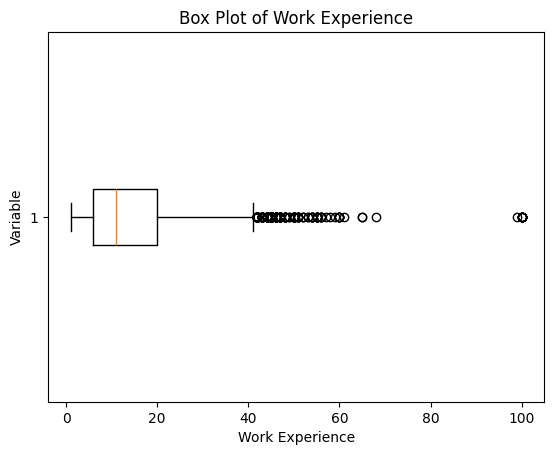

In [283]:
import matplotlib.pyplot as plt

plt.boxplot(df_selected["WorkExp"], vert=False)
plt.ylabel("Variable")
plt.xlabel("Work Experience")
plt.title("Box Plot of Work Experience")
plt.show()

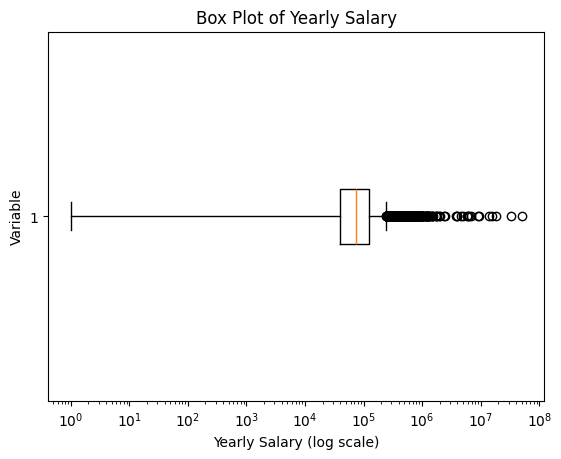

In [284]:
import matplotlib.pyplot as plt

plt.boxplot(df_selected["ConvertedCompYearly"], vert=False)
plt.xscale("log")
plt.ylabel("Variable")
plt.xlabel("Yearly Salary (log scale)")
plt.title("Box Plot of Yearly Salary")
plt.show()

In [285]:
mean_work = df_selected["WorkExp"].mean()
std_work = df_selected["WorkExp"].std()

lower_bound = mean_work - 2 * std_work
upper_bound = mean_work + 2 * std_work

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df_test = df_selected[
    (df_selected["WorkExp"] >= lower_bound) &
    (df_selected["WorkExp"] <= upper_bound)
]

print("Original rows:", len(df_selected))
print("Rows after filtering:", len(df_test))

Lower bound: -6.54264141552386
Upper bound: 33.929457229715645
Original rows: 23422
Rows after filtering: 22282


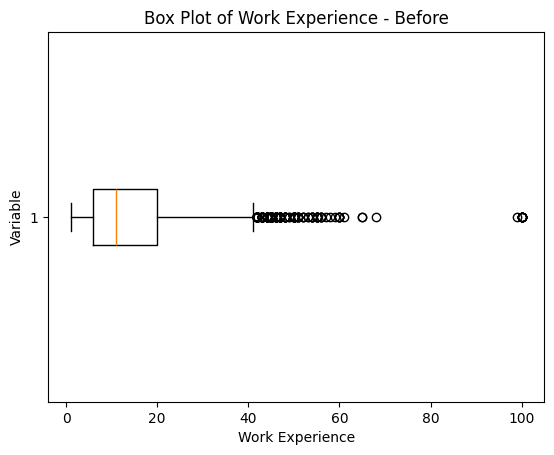

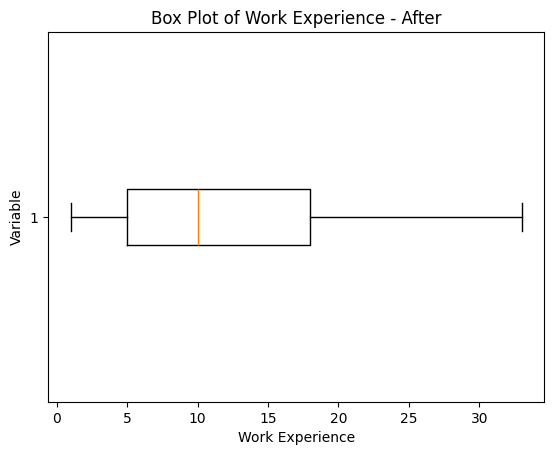

In [286]:
import matplotlib.pyplot as plt

plt.boxplot(df_selected["WorkExp"], vert=False)
plt.ylabel("Variable")
plt.xlabel("Work Experience")
plt.title("Box Plot of Work Experience - Before")
plt.show()

plt.boxplot(df_test["WorkExp"], vert=False)
plt.ylabel("Variable")
plt.xlabel("Work Experience")
plt.title("Box Plot of Work Experience - After")
plt.show()

In [287]:
Q1_work = df_selected["WorkExp"].quantile(0.25)
Q3_work = df_selected["WorkExp"].quantile(0.75)
IQR_work = Q3_work - Q1_work

lower_work = Q1_work - 1.5 * IQR_work
upper_work = Q3_work + 1.5 * IQR_work

print("WorkExp IQR bounds:")
print("Q1:", Q1_work)
print("Q3:", Q3_work)
print("IQR:", IQR_work)
print("Lower bound:", lower_work)
print("Upper bound:", upper_work)

df_work_iqr = df_selected[
    (df_selected["WorkExp"] >= lower_work) &
    (df_selected["WorkExp"] <= upper_work)
]

print("Original rows:", len(df_selected))
print("Rows after WorkExp IQR filtering:", len(df_work_iqr))

WorkExp IQR bounds:
Q1: 6.0
Q3: 20.0
IQR: 14.0
Lower bound: -15.0
Upper bound: 41.0
Original rows: 23422
Rows after WorkExp IQR filtering: 23126


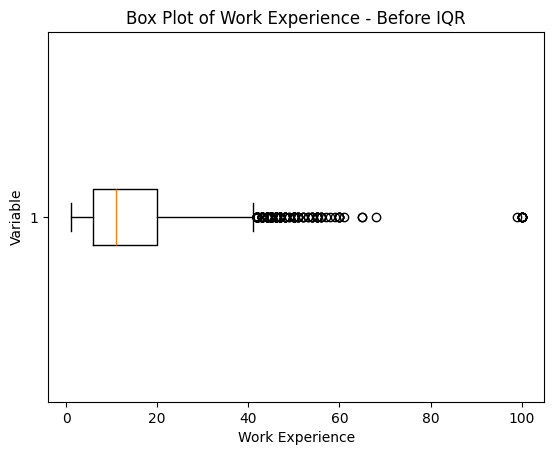

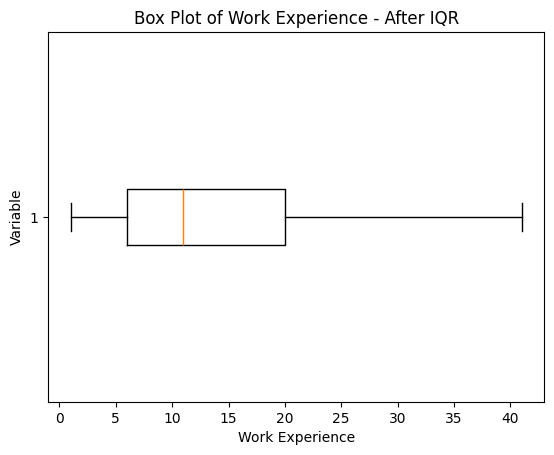

In [288]:
import matplotlib.pyplot as plt

plt.boxplot(df_selected["WorkExp"], vert=False)
plt.ylabel("Variable")
plt.xlabel("Work Experience")
plt.title("Box Plot of Work Experience - Before IQR")
plt.show()

plt.boxplot(df_work_iqr["WorkExp"], vert=False)
plt.ylabel("Variable")
plt.xlabel("Work Experience")
plt.title("Box Plot of Work Experience - After IQR")
plt.show()

Original count: 23422

Mean method:
Lower bound: -821456.646613969
Upper bound: 1027366.0263424295
Remaining rows: 23379

IQR method:
Lower bound: -82843.0
Upper bound: 245749.0
Remaining rows: 22392


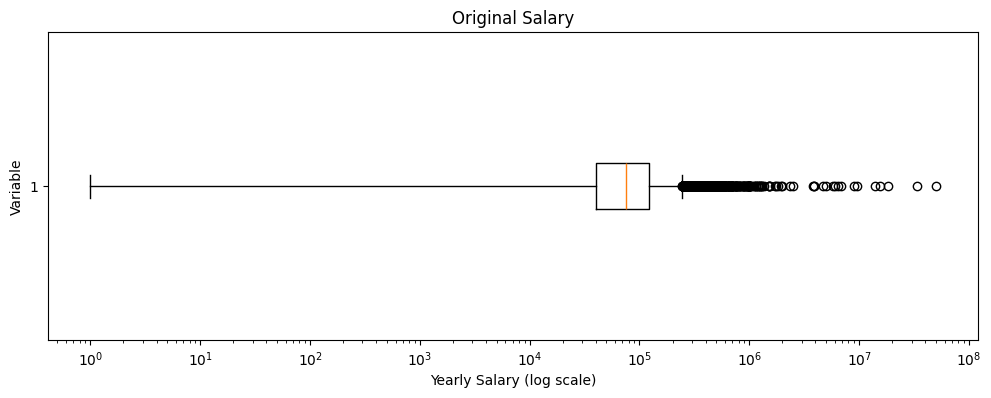

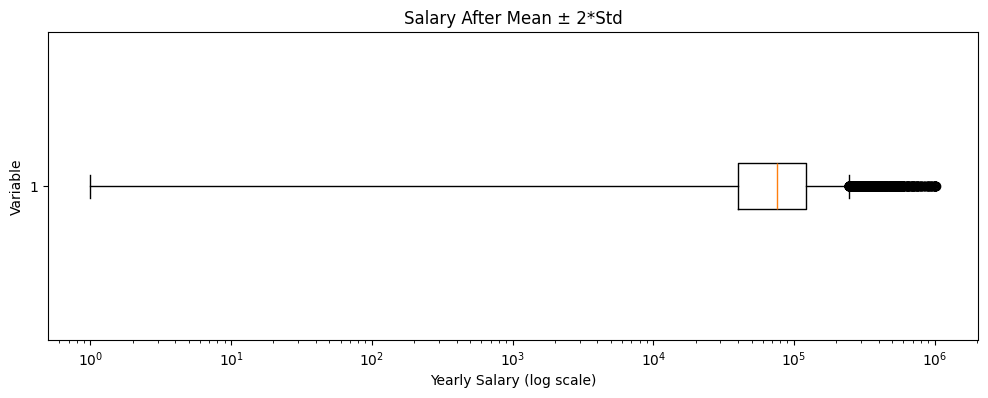

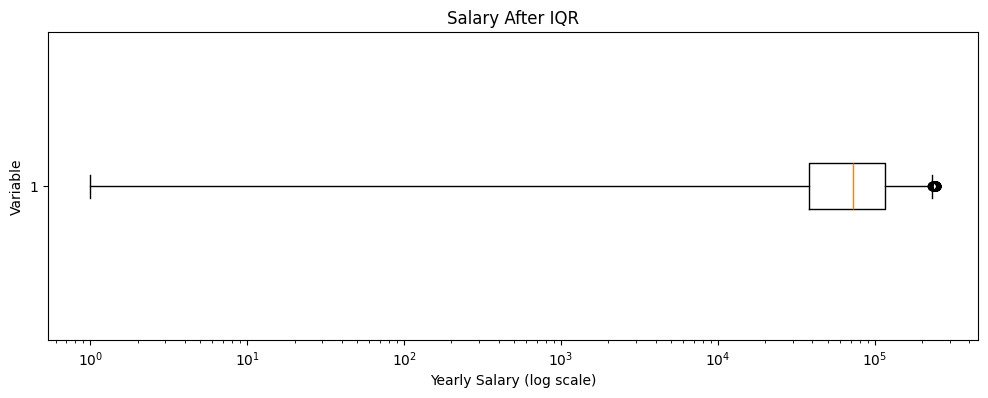

In [289]:
import matplotlib.pyplot as plt

# Original salary
salary_original = df_selected["ConvertedCompYearly"]

# Mean ± 2*std method
mean_salary = salary_original.mean()
std_salary = salary_original.std()

lower_mean = mean_salary - 2 * std_salary
upper_mean = mean_salary + 2 * std_salary

salary_mean = salary_original[
    (salary_original >= lower_mean) & (salary_original <= upper_mean)
]

# IQR method
Q1 = salary_original.quantile(0.25)
Q3 = salary_original.quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

salary_iqr = salary_original[
    (salary_original >= lower_iqr) & (salary_original <= upper_iqr)
]

# Print counts and bounds
print("Original count:", len(salary_original))

print("\nMean method:")
print("Lower bound:", lower_mean)
print("Upper bound:", upper_mean)
print("Remaining rows:", len(salary_mean))

print("\nIQR method:")
print("Lower bound:", lower_iqr)
print("Upper bound:", upper_iqr)
print("Remaining rows:", len(salary_iqr))

# Plot 3 separate figures
plt.figure(figsize=(12, 4))
plt.boxplot(salary_original, vert=False)
plt.xscale("log")
plt.ylabel("Variable")
plt.xlabel("Yearly Salary (log scale)")
plt.title("Original Salary")
plt.show()

plt.figure(figsize=(12, 4))
plt.boxplot(salary_mean, vert=False)
plt.xscale("log")
plt.ylabel("Variable")
plt.xlabel("Yearly Salary (log scale)")
plt.title("Salary After Mean ± 2*Std")
plt.show()

plt.figure(figsize=(12, 4))
plt.boxplot(salary_iqr, vert=False)
plt.xscale("log")
plt.ylabel("Variable")
plt.xlabel("Yearly Salary (log scale)")
plt.title("Salary After IQR")
plt.show()

In [290]:
Q1_work = df_selected["WorkExp"].quantile(0.25)
Q3_work = df_selected["WorkExp"].quantile(0.75)
IQR_work = Q3_work - Q1_work

lower_work = Q1_work - 1.5 * IQR_work
upper_work = Q3_work + 1.5 * IQR_work

Q1_salary = df_selected["ConvertedCompYearly"].quantile(0.25)
Q3_salary = df_selected["ConvertedCompYearly"].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary

lower_salary = Q1_salary - 1.5 * IQR_salary
upper_salary = Q3_salary + 1.5 * IQR_salary

df_selected = df_selected[
    (df_selected["WorkExp"] >= lower_work) &
    (df_selected["WorkExp"] <= upper_work) &
    (df_selected["ConvertedCompYearly"] >= lower_salary) &
    (df_selected["ConvertedCompYearly"] <= upper_salary)
]

print("WorkExp bounds:", lower_work, upper_work)
print("Salary bounds:", lower_salary, upper_salary)
print("New shape:", df_selected.shape)

WorkExp bounds: -15.0 41.0
Salary bounds: -82843.0 245749.0
New shape: (22122, 5)


In [291]:
print("describe WorkExp:")
print(df_selected["WorkExp"].describe())

print("\ndescribe ConvertedCompYearly:")
print(df_selected["ConvertedCompYearly"].describe())

describe WorkExp:
count    22122.000000
mean        13.034084
std          9.275657
min          1.000000
25%          5.000000
50%         11.000000
75%         19.000000
max         41.000000
Name: WorkExp, dtype: float64

describe ConvertedCompYearly:
count     22122.000000
mean      80755.013832
std       56270.540726
min           1.000000
25%       37999.000000
50%       72958.000000
75%      116015.000000
max      245055.000000
Name: ConvertedCompYearly, dtype: float64


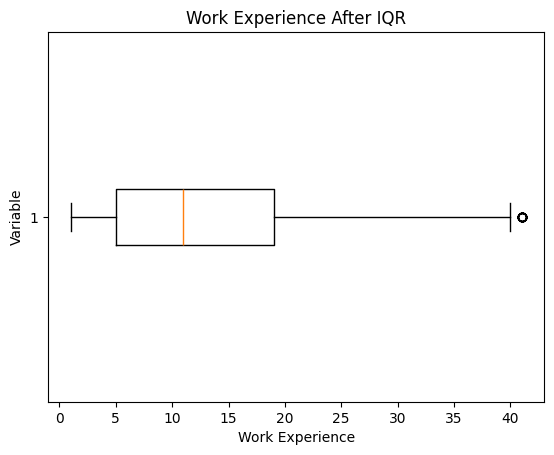

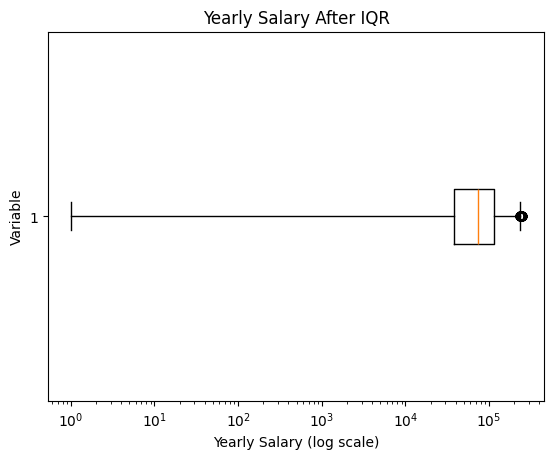

In [292]:
import matplotlib.pyplot as plt

plt.boxplot(df_selected["WorkExp"], vert=False)
plt.ylabel("Variable")
plt.xlabel("Work Experience")
plt.title("Work Experience After IQR")
plt.show()

plt.boxplot(df_selected["ConvertedCompYearly"], vert=False)
plt.xscale("log")
plt.ylabel("Variable")
plt.xlabel("Yearly Salary (log scale)")
plt.title("Yearly Salary After IQR")
plt.show()

In [293]:
df_selected.to_csv("data/cleaned_developer_survey.csv", index=False)

In [294]:
df_selected.info()

<class 'pandas.DataFrame'>
Index: 22122 entries, 0 to 49017
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   WorkExp              22122 non-null  float64
 1   EdLevel              22122 non-null  str    
 2   LearnCodeChoose      22122 non-null  str    
 3   LearnCode            22122 non-null  str    
 4   ConvertedCompYearly  22122 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.0 MB


In [295]:
exp_salary = (
    df_selected
    .groupby("WorkExp")["ConvertedCompYearly"]
    .agg(["count", "mean", "median"])
    .round(2)
    .reset_index()
)

exp_salary

,WorkExp,count,mean,median
0,1.0,853,31586.88,20342.0
1,2.0,1075,36268.74,24000.0
2,3.0,1256,43213.99,35477.0
3,4.0,1120,48193.65,40605.0
4,5.0,1281,56898.18,50000.0
5,6.0,1009,66407.67,60444.0
6,7.0,996,72283.05,67321.5
7,8.0,1120,76601.26,69609.0
8,9.0,722,82372.89,74249.0
9,10.0,1536,84835.55,79261.0


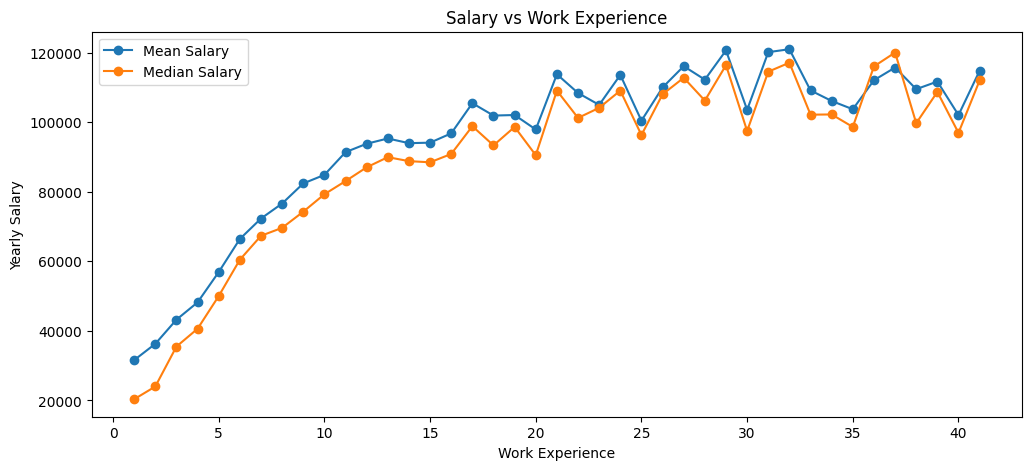

In [296]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(exp_salary["WorkExp"], exp_salary["mean"], marker="o", label="Mean Salary")
plt.plot(exp_salary["WorkExp"], exp_salary["median"], marker="o", label="Median Salary")
plt.xlabel("Work Experience")
plt.ylabel("Yearly Salary")
plt.title("Salary vs Work Experience")
plt.legend()
plt.show()

In [297]:
ed_salary = (
    df_selected
    .groupby("EdLevel")["ConvertedCompYearly"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
    .reset_index()
)

ed_salary

,EdLevel,count,mean,median
0,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",1219,90978.15,83531.0
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",6476,84326.16,76570.0
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",9653,81688.88,74000.0
3,"Associate degree (A.A., A.S., etc.)",755,76809.78,69400.0
4,Some college/university study without earning ...,2626,75057.38,65009.0
5,"Secondary school (e.g. American high school, G...",1080,62037.37,54458.5
6,Other (please specify):,200,59352.40,50680.0
7,Primary/elementary school,113,61577.20,48726.0


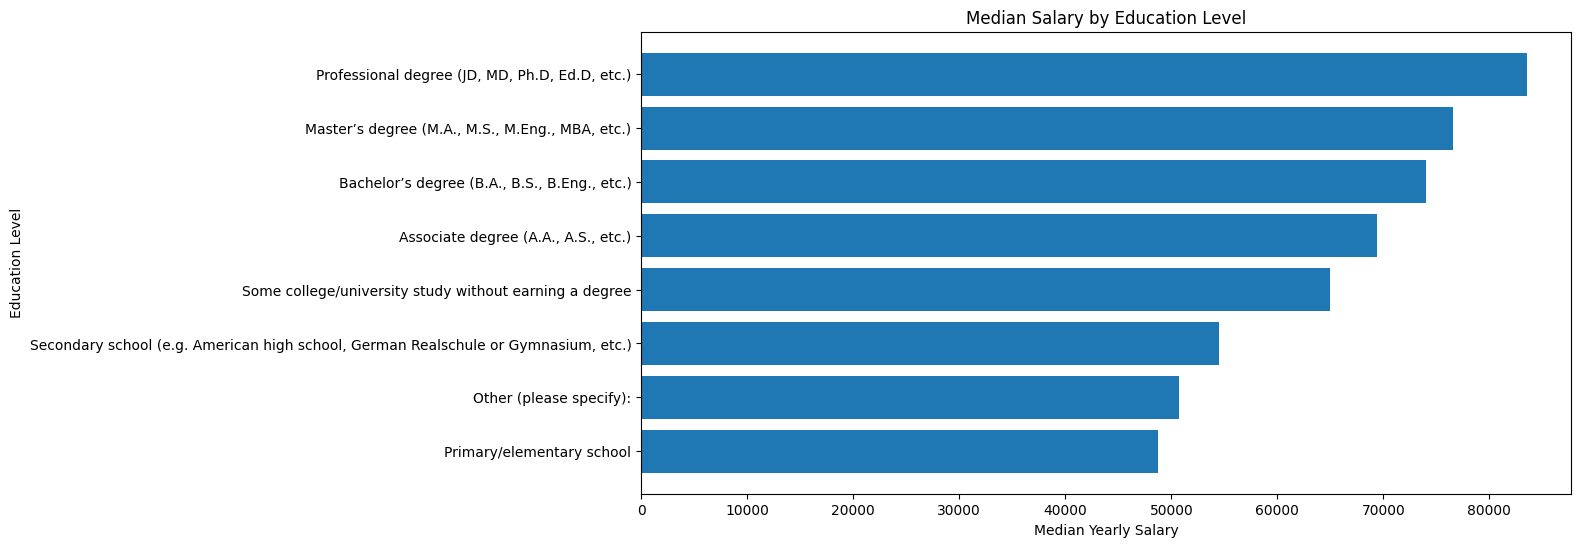

In [298]:
plt.figure(figsize=(12, 6))
plt.barh(ed_salary["EdLevel"], ed_salary["median"])
plt.xlabel("Median Yearly Salary")
plt.ylabel("Education Level")
plt.title("Median Salary by Education Level")
plt.gca().invert_yaxis()
plt.show()

In [299]:
learn_choose_salary = (
    df_selected
    .groupby("LearnCodeChoose")["ConvertedCompYearly"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("median", ascending=False)
    .reset_index()
)

learn_choose_salary

,LearnCodeChoose,count,mean,median
0,"No, I am not new to coding and did not learn n...",6318,89863.98,81870.0
1,"Yes, I am not new to coding but am learning ne...",15417,78248.08,69609.0
2,"Yes, I am new to coding or currently a student",387,31915.24,10000.0


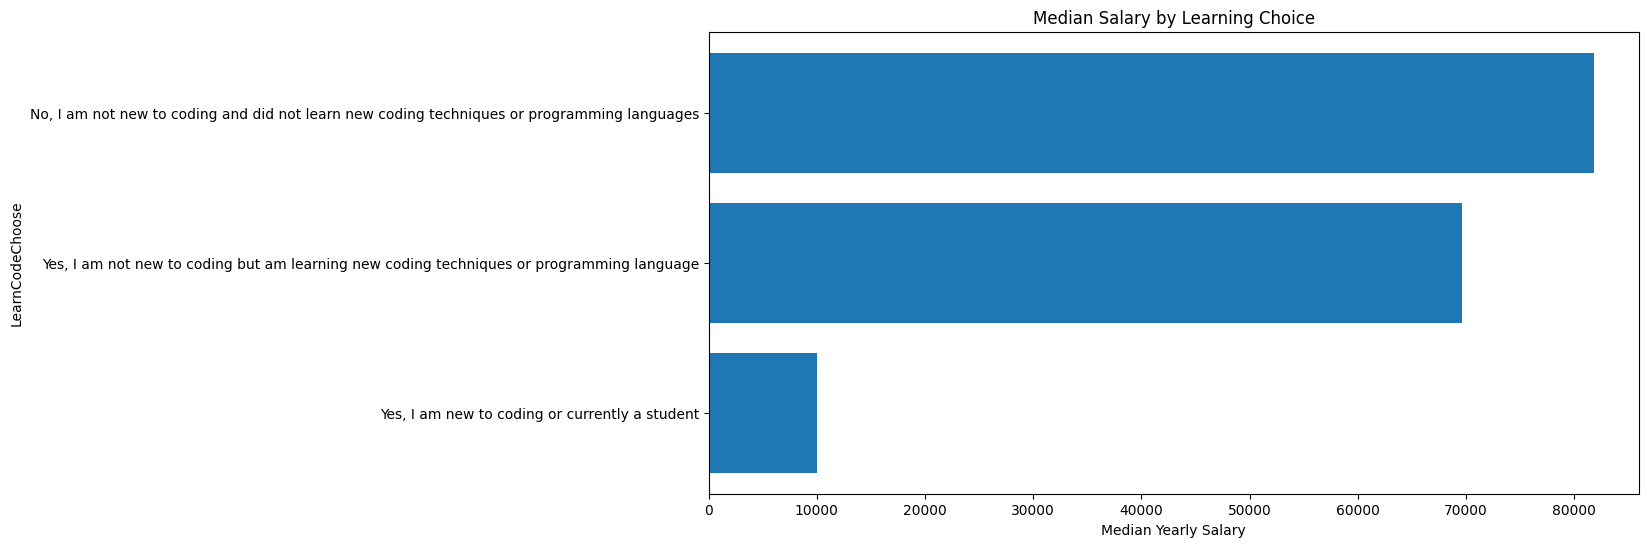

In [300]:
plt.figure(figsize=(12, 6))
plt.barh(learn_choose_salary["LearnCodeChoose"], learn_choose_salary["median"])
plt.xlabel("Median Yearly Salary")
plt.ylabel("LearnCodeChoose")
plt.title("Median Salary by Learning Choice")
plt.gca().invert_yaxis()
plt.show()

In [301]:
print("Education groups:")
print(ed_salary[["EdLevel", "count", "mean", "median"]])

print("\nLearning choice groups:")
print(learn_choose_salary[["LearnCodeChoose", "count", "mean", "median"]])

Education groups:
                                             EdLevel  count      mean   median
0     Professional degree (JD, MD, Ph.D, Ed.D, etc.)   1219  90978.15  83531.0
1    Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   6476  84326.16  76570.0
2       Bachelor’s degree (B.A., B.S., B.Eng., etc.)   9653  81688.88  74000.0
3                Associate degree (A.A., A.S., etc.)    755  76809.78  69400.0
4  Some college/university study without earning ...   2626  75057.38  65009.0
5  Secondary school (e.g. American high school, G...   1080  62037.37  54458.5
6                            Other (please specify):    200  59352.40  50680.0
7                          Primary/elementary school    113  61577.20  48726.0

Learning choice groups:
                                     LearnCodeChoose  count      mean   median
0  No, I am not new to coding and did not learn n...   6318  89863.98  81870.0
1  Yes, I am not new to coding but am learning ne...  15417  78248.08  69609.0
2     Yes

In [302]:
exp_salary.to_csv("data/results_experience_salary.csv", index=False)
ed_salary.to_csv("data/results_education_salary.csv", index=False)
learn_choose_salary.to_csv("data/results_learningchoice_salary.csv", index=False)

In [303]:
df_selected["HasCertificationLearning"] = df_selected["LearnCode"].str.contains(
    "Online Courses or Certification",
    case=False,
    na=False
)

In [304]:
cert_exp_salary = (
    df_selected
    .groupby(["WorkExp", "HasCertificationLearning"])["ConvertedCompYearly"]
    .median()
    .reset_index()
)

cert_exp_pivot = cert_exp_salary.pivot(
    index="WorkExp",
    columns="HasCertificationLearning",
    values="ConvertedCompYearly"
)

cert_exp_pivot

HasCertificationLearning,False,True
WorkExp,,
1.0,24744.0,11624.0
2.0,30164.0,14400.0
3.0,40000.0,25523.0
4.0,43993.0,34804.0
5.0,54212.0,36866.0
6.0,62864.5,53367.0
7.0,70104.0,47966.0
8.0,71929.0,60000.0
9.0,76000.0,64968.0


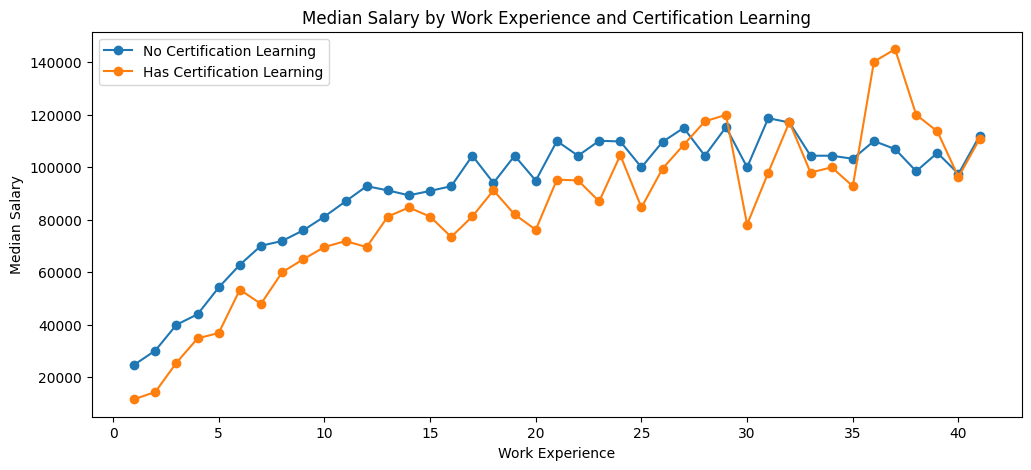

In [305]:
line_data = (
    df_selected
    .groupby(["WorkExp", "HasCertificationLearning"])["ConvertedCompYearly"]
    .median()
    .reset_index()
)

yes_data = line_data[line_data["HasCertificationLearning"] == True]
no_data = line_data[line_data["HasCertificationLearning"] == False]

plt.figure(figsize=(12, 5))
plt.plot(no_data["WorkExp"], no_data["ConvertedCompYearly"], marker="o", label="No Certification Learning")
plt.plot(yes_data["WorkExp"], yes_data["ConvertedCompYearly"], marker="o", label="Has Certification Learning")

plt.xlabel("Work Experience")
plt.ylabel("Median Salary")
plt.title("Median Salary by Work Experience and Certification Learning")
plt.legend()
plt.show()

In [306]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from pathlib import Path

cleaned_path = Path("data/cleaned_developer_survey.csv")

if "df_selected" in globals():
    ml_df = df_selected.copy()
elif cleaned_path.exists():
    ml_df = pd.read_csv(cleaned_path)
else:
    raise FileNotFoundError(
        "Run the cleaning cells first, or place data/cleaned_developer_survey.csv in the data folder."
    )

features = ["WorkExp", "EdLevel", "LearnCodeChoose", "LearnCode", "HasCertificationLearning"]
target = "ConvertedCompYearly"

ml_df = ml_df[features + [target]].copy()
ml_df = ml_df.dropna(subset=[target])

numeric_features = ["WorkExp"]
categorical_features = ["EdLevel", "LearnCodeChoose", "LearnCode", "HasCertificationLearning"]

# Force stable dtypes before sklearn pipelines.
ml_df["WorkExp"] = pd.to_numeric(ml_df["WorkExp"], errors="coerce")
for col in categorical_features:
    ml_df[col] = ml_df[col].fillna("Unknown").astype(str)

ml_df = ml_df.dropna(subset=["WorkExp"])

X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

models = {
    "baseline_median": DummyRegressor(strategy="median"),
    "ridge_regression": Ridge(alpha=1.0),
    "random_forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=10,
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model),
        ]
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    results.append(
        {
            "model": name,
            "mae": mean_absolute_error(y_test, predictions),
            "rmse": np.sqrt(mean_squared_error(y_test, predictions)),
            "r2": r2_score(y_test, predictions),
        }
    )
    fitted_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("mae")
results_df

,model,mae,rmse,r2
2,random_forest,40109.441932,51259.538297,0.192037
1,ridge_regression,41226.899266,52331.104615,0.157904
0,baseline_median,45519.753220,57686.544916,-0.023272


In [307]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
predicted_y = best_model.predict(X_test)

comparison_df = X_test.copy()
comparison_df["actual_y"] = y_test.values
comparison_df["predicted_y"] = predicted_y.round(0)
comparison_df["prediction_error"] = comparison_df["actual_y"] - comparison_df["predicted_y"]

comparison_df.head(10)

,WorkExp,EdLevel,LearnCodeChoose,LearnCode,HasCertificationLearning,actual_y,predicted_y,prediction_error
4004,11.0,"Secondary school (e.g. American high school, G...","Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",False,87011.0,80139.0,6872.0
40988,1.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Yes, I am not new to coding but am learning ne...",Videos (not associated with specific online co...,False,37439.0,36579.0,860.0
30161,6.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Yes, I am not new to coding but am learning ne...",Videos (not associated with specific online co...,False,139864.0,66834.0,73030.0
5136,30.0,"Secondary school (e.g. American high school, G...","No, I am not new to coding and did not learn n...",Unknown,False,126361.0,122576.0,3785.0
34603,4.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","No, I am not new to coding and did not learn n...",Unknown,False,8369.0,46623.0,-38254.0
17100,7.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","No, I am not new to coding and did not learn n...",Unknown,False,35949.0,77025.0,-41076.0
26404,8.0,Some college/university study without earning ...,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",False,45103.0,64656.0,-19553.0
11144,20.0,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","No, I am not new to coding and did not learn n...",Unknown,False,34700.0,97059.0,-62359.0
46407,7.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,True,23966.0,56253.0,-32287.0
38860,14.0,Some college/university study without earning ...,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,True,109438.0,109379.0,59.0
